# PointNet (ShapeNetPart) — Runpod Notebook
Self-contained workflow for the bonus segmentation track: convert the raw ShapeNetPart annotations, clone the official PointNet repo, patch it for Runpod, train/fine-tune `train_partseg.py`, evaluate mIoU, and export artifacts.


In [39]:
#@title 0) System info
import os
import platform
import subprocess
import sys
from datetime import datetime

print('Python:', sys.version)
print('Platform:', platform.platform())
try:
    import torch
    print('PyTorch:', torch.__version__)
    print('CUDA in torch:', torch.version.cuda)
    print('CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU count:', torch.cuda.device_count())
        for idx in range(torch.cuda.device_count()):
            props = torch.cuda.get_device_properties(idx)
            print(f"  - cuda:{idx} -> {props.name} ({props.total_memory/1e9:.1f} GB)")
except ImportError:
    print('PyTorch not installed; install it before running training cells.')
print('Working dir:', os.getcwd())
print('Timestamp:', datetime.now())


Python: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Platform: Linux-6.11.0-26-generic-x86_64-with-glibc2.39
PyTorch: 2.8.0+cu128
CUDA in torch: 12.8
CUDA available: True
GPU count: 1
  - cuda:0 -> NVIDIA GeForce RTX 5090 (33.7 GB)
Working dir: /workspace/comp3419_A2b
Timestamp: 2025-11-12 14:07:16.905284


In [40]:
#@title 1) Config — paths & hyper-parameters
from pathlib import Path

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path().resolve()

RAW_BASE = NOTEBOOK_DIR / 'PartAnnotation'
OUT_ROOT = NOTEBOOK_DIR / 'shapenetcore_partanno_segmentation_benchmark_v0_normal'
REPO_URL = 'https://github.com/yanx27/Pointnet_Pointnet2_pytorch.git'
REPO_BRANCH = 'master'
REPO_SUBDIR = 'Pointnet_Pointnet2_pytorch'
EXP_NAME = 'pointnet_partseg_xyz_runpod'
NUM_POINTS = 2048
BATCH_SIZE = 16
EPOCHS = 250
LEARNING_RATE = 0.001
NUM_WORKERS = 12
PIN_MEMORY = True
AUTO_FETCH_DATASET = False
INSTALL_REQUIREMENTS = True
APPLY_RUNPOD_PATCH = True

REPO_DIR = (NOTEBOOK_DIR / REPO_SUBDIR).resolve()
REPO_MARKER = REPO_DIR / '.prepared_from_git'
DATA_PATH = OUT_ROOT
LOG_BASE = REPO_DIR / 'log' / 'part_seg' / EXP_NAME
LOG_BASE.mkdir(parents=True, exist_ok=True)
print('Notebook dir :', NOTEBOOK_DIR)
print('Raw ShapeNet :', RAW_BASE)
print('Processed out :', OUT_ROOT)
print('Repo dir      :', REPO_DIR)
print('Log dir       :', LOG_BASE)


Notebook dir : /workspace/comp3419_A2b
Raw ShapeNet : /workspace/comp3419_A2b/PartAnnotation
Processed out : /workspace/comp3419_A2b/shapenetcore_partanno_segmentation_benchmark_v0_normal
Repo dir      : /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch
Log dir       : /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod


In [41]:
#@title 2) Verify raw dataset availability
if not RAW_BASE.exists():
    raise FileNotFoundError(f'RAW_BASE missing at {RAW_BASE}. Please place the ShapeNetPart PartAnnotation tree there.')
print('Found RAW dataset under', RAW_BASE)


Found RAW dataset under /workspace/comp3419_A2b/PartAnnotation


In [42]:
#@title 3) Convert raw PartAnnotation → PointNet txt format
import glob
import json
import numpy as np
import os
import shutil

SEG_CLASSES = {
    'Airplane': [0, 1, 2, 3],
    'Bag': [4, 5],
    'Cap': [6, 7],
    'Car': [8, 9, 10, 11],
    'Chair': [12, 13, 14, 15],
    'Earphone': [16, 17, 18],
    'Guitar': [19, 20, 21],
    'Knife': [22, 23],
    'Lamp': [24, 25, 26, 27],
    'Laptop': [28, 29],
    'Motorbike': [30, 31, 32, 33, 34, 35],
    'Mug': [36, 37],
    'Pistol': [38, 39, 40],
    'Rocket': [41, 42, 43],
    'Skateboard': [44, 45, 46],
    'Table': [47, 48, 49],
}

def extract_uuid(path_str):
    base = os.path.basename(path_str)
    name, _ = os.path.splitext(base)
    return name


def load_list(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return {extract_uuid(entry) for entry in data}


def ensure_split_files(raw_base, out_root):
    split_dir = out_root / 'train_test_split'
    if split_dir.exists():
        return
    cand = list(raw_base.glob('**/train_test_split'))
    if not cand:
        raise RuntimeError('train_test_split folder not found under RAW_BASE')
    split_dir.mkdir(parents=True, exist_ok=True)
    for name in ['shuffled_train_file_list.json', 'shuffled_val_file_list.json', 'shuffled_test_file_list.json']:
        src = cand[0] / name
        if not src.exists():
            raise RuntimeError(f'Missing {src}')
        shutil.copy2(src, split_dir / name)
    synmap = cand[0].parent / 'synsetoffset2category.txt'
    if synmap.exists():
        shutil.copy2(synmap, out_root / 'synsetoffset2category.txt')


def load_synset_map(out_root):
    mapping_file = out_root / 'synsetoffset2category.txt'
    if not mapping_file.exists():
        raise RuntimeError('synsetoffset2category.txt missing under processed dataset root')
    syn_to_name = {}
    with mapping_file.open() as f:
        for line in f:
            name, syn = line.strip().split('	')
            syn_to_name[syn] = name
    return syn_to_name


def convert_raw_to_txt(raw_base, out_root):
    ensure_split_files(raw_base, out_root)
    split_dir = out_root / 'train_test_split'
    train_ids = load_list(split_dir / 'shuffled_train_file_list.json')
    val_ids = load_list(split_dir / 'shuffled_val_file_list.json')
    test_ids = load_list(split_dir / 'shuffled_test_file_list.json')
    allowed = train_ids | val_ids | test_ids
    syn_to_name = load_synset_map(out_root)
    wrote = 0

    def find_seg(labels_dir, uuid):
        direct = labels_dir / f"{uuid}.seg"
        if direct.exists():
            return direct
        matches = list(labels_dir.rglob(f"{uuid}.seg"))
        return matches[0] if matches else None

    def remap_labels(seg_values, synset):
        name = syn_to_name.get(synset)
        if not name or name not in SEG_CLASSES:
            return seg_values
        parts = SEG_CLASSES[name]
        mapped = np.array([parts[int(idx)] for idx in seg_values], dtype=np.int32)
        return mapped

    def write_record(pts_path, seg_path, synset):
        nonlocal wrote
        pts = np.loadtxt(pts_path).astype(np.float32)
        if pts.ndim == 1:
            pts = pts.reshape(-1, pts.shape[0])
        seg = np.loadtxt(seg_path).astype(np.int32).reshape(-1)
        n = min(len(pts), len(seg))
        if n == 0:
            return
        pts = pts[:n, :3]
        seg = remap_labels(seg[:n], synset)
        zeros = np.zeros((n, 3), dtype=np.float32)
        out = np.concatenate([pts, zeros, seg.reshape(-1, 1)], axis=1)
        dst = out_root / synset
        dst.mkdir(parents=True, exist_ok=True)
        np.savetxt(dst / f"{pts_path.stem}.txt", out, fmt='%.6f %.6f %.6f %.6f %.6f %.6f %d')
        wrote += 1

    for syn_dir in sorted(raw_base.iterdir()):
        if not syn_dir.is_dir():
            continue
        synset = syn_dir.name
        points_dir = syn_dir / 'points'
        labels_dir = syn_dir / 'points_label'
        if points_dir.exists() and labels_dir.exists():
            for pts_path in points_dir.glob('*.pts'):
                uuid = pts_path.stem
                if uuid not in allowed:
                    continue
                seg_path = find_seg(labels_dir, uuid)
                if seg_path is None:
                    continue
                write_record(pts_path, seg_path, synset)
            continue
        for uuid_dir in syn_dir.iterdir():
            if not uuid_dir.is_dir():
                continue
            uuid = uuid_dir.name
            if uuid not in allowed:
                continue
            pts_candidates = list((uuid_dir / 'points').glob('*.pts')) if (uuid_dir / 'points').exists() else list(uuid_dir.glob('*.pts'))
            seg_candidates = list((uuid_dir / 'points_label').glob('*.seg'))
            if (uuid_dir / 'seg').exists():
                seg_candidates += list((uuid_dir / 'seg').glob('*.seg'))
            seg_candidates += list(uuid_dir.glob('*.seg'))
            if not pts_candidates or not seg_candidates:
                continue
            write_record(pts_candidates[0], seg_candidates[0], synset)
    print('Converted samples:', wrote)
    print('PointNet txt files at:', out_root)

OUT_ROOT.mkdir(parents=True, exist_ok=True)
existing = list(OUT_ROOT.glob('*/*.txt'))
if existing:
    print('Found', len(existing), '.txt files — skipping conversion.')
else:
    convert_raw_to_txt(RAW_BASE, OUT_ROOT)


Converted samples: 16835
PointNet txt files at: /workspace/comp3419_A2b/shapenetcore_partanno_segmentation_benchmark_v0_normal


In [43]:
#@title 4) Clone/Pull official PointNet repo + install deps
import subprocess
import sys
import shutil
import time

repo_git = REPO_DIR / '.git'
repo_marker = REPO_MARKER

def stamp_repo(message):
    stamp_line = f"{message} @ {time.ctime()}"
    repo_marker.write_text(stamp_line + "\n")

def ensure_repo_materialized():
    if REPO_DIR.exists():
        if repo_git.exists():
            print('PointNet repo with git metadata already present at', REPO_DIR)
            if not repo_marker.exists():
                stamp_repo('existing git checkout')
            return False
        if repo_marker.exists():
            print('PointNet source already prepared at', REPO_DIR)
            return False
        print('PointNet directory exists without git metadata; marking it as prepared (manual copy).')
        stamp_repo('manual copy')
        return False
    print('Cloning PointNet fresh into', REPO_DIR)
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(['git', 'clone', '--depth', '1', '--branch', REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)
    if repo_git.exists():
        shutil.rmtree(repo_git)
    stamp_repo('cloned from upstream')
    return True

ensure_repo_materialized()
if INSTALL_REQUIREMENTS:
    req = REPO_DIR / 'requirements.txt'
    if req.exists():
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(req)], check=False)
    extras = ['h5py', 'scikit-learn', 'tqdm', 'matplotlib']
    subprocess.run([sys.executable, '-m', 'pip', 'install', *extras], check=False)
print('Repo ready at', REPO_DIR)



Repo already exists at /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch - assuming newest.
Repo ready at /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch


In [44]:
#@title 5) Patch part-seg scripts for Runpod
from pathlib import Path

repo_git = REPO_DIR / '.git'
repo_marker = REPO_MARKER
if not REPO_DIR.exists():
    raise FileNotFoundError('PointNet repo missing; run the clone cell first.')
if repo_git.exists() and not repo_marker.exists():
    print('PointNet repo still has git metadata; consider removing it if you do not intend to treat it as a submodule.')


train_file = REPO_DIR / 'train_partseg.py'
test_file = REPO_DIR / 'test_partseg.py'

def add_backend_block(text):
    marker = 'torch.backends.cudnn.benchmark = True'
    if marker in text:
        return text
    insert_after = "import torch\n"
    block = (
        "\n"
        "torch.backends.cudnn.benchmark = True\n"
        "if hasattr(torch.backends.cuda, 'matmul') and hasattr(torch.backends.cuda.matmul, 'allow_tf32'):\n"
        "    torch.backends.cuda.matmul.allow_tf32 = True\n"
        "if hasattr(torch, 'set_float32_matmul_precision'):\n"
        "    torch.set_float32_matmul_precision('high')\n"
    )
    return text.replace(insert_after, insert_after + block, 1)

def add_parser_args_train(text):
    if '--pin_memory' in text:
        return text
    snippet = (
        "    parser.add_argument('--num_workers', type=int, default=10, help='number of workers for dataloaders')\n"
        "    parser.add_argument('--pin_memory', action='store_true', default=False, help='pin memory flag')\n"
    )
    target = "    parser.add_argument('--lr_decay', type=float, default=0.5, help='decay rate for lr decay')\n\n"
    return text.replace(target, target + snippet + "\n", 1)

def add_parser_args_test(text):
    if '--pin_memory' in text:
        return text
    snippet = (
        "    parser.add_argument('--num_workers', type=int, default=10, help='number of workers for dataloaders')\n"
        "    parser.add_argument('--pin_memory', action='store_true', default=False, help='pin memory flag')\n"
    )
    target = "    parser.add_argument('--num_votes', type=int, default=3, help='aggregate segmentation scores with voting')\n"
    return text.replace(target, target + snippet + "\n", 1)

TRAIN_LOAD_OLD = "        checkpoint = torch.load(str(exp_dir) + '/checkpoints/best_model.pth')"
TRAIN_LOAD_NEW = "        checkpoint = torch.load(str(exp_dir) + '/checkpoints/best_model.pth', weights_only=False)"
TEST_LOAD_OLD = "    checkpoint = torch.load(str(experiment_dir) + '/checkpoints/best_model.pth')"
TEST_LOAD_NEW = "    checkpoint = torch.load(str(experiment_dir) + '/checkpoints/best_model.pth', weights_only=False)"

def replace_num_workers(text):
    text = text.replace('num_workers=10', 'num_workers=args.num_workers, pin_memory=args.pin_memory')
    text = text.replace('num_workers=4', 'num_workers=args.num_workers, pin_memory=args.pin_memory')
    return text

def apply_patches(path, replacements):
    text = path.read_text()
    original = text
    for func in replacements:
        text = func(text)
    if text != original:
        path.write_text(text)
        print('Patched', path.name)
    else:
        print('Already patched', path.name)

if APPLY_RUNPOD_PATCH:
    apply_patches(train_file, [
        add_backend_block,
        add_parser_args_train,
        replace_num_workers,
        lambda txt: txt.replace(TRAIN_LOAD_OLD, TRAIN_LOAD_NEW),
    ])
    apply_patches(test_file, [
        add_backend_block,
        add_parser_args_test,
        replace_num_workers,
        lambda txt: txt.replace(TEST_LOAD_OLD, TEST_LOAD_NEW),
    ])
else:
    print('APPLY_RUNPOD_PATCH is False — skipping patch step.')


Already patched train_partseg.py
Already patched test_partseg.py


In [45]:
#@title 6) Link processed dataset into repo
import os
import shutil

repo_data = REPO_DIR / 'data'
repo_data.mkdir(exist_ok=True)
expected = repo_data / 'shapenetcore_partanno_segmentation_benchmark_v0_normal'
if expected.exists() or expected.is_symlink():
    if expected.is_symlink():
        expected.unlink()
    else:
        shutil.rmtree(expected)
try:
    expected.symlink_to(OUT_ROOT, target_is_directory=True)
    print('Symlinked dataset ->', expected)
except OSError:
    shutil.copytree(OUT_ROOT, expected)
    print('Copied dataset into repo data dir')


Symlinked dataset -> /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/data/shapenetcore_partanno_segmentation_benchmark_v0_normal


In [46]:
#@title 7) Helper functions (training/testing)
import os
import shlex
import subprocess
import sys
from pathlib import Path

LOG_DIR = REPO_DIR / 'log' / 'part_seg' / EXP_NAME
LOG_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT = LOG_DIR / 'checkpoints' / 'best_model.pth'


def run_cmd(cmd, log_file):
    print('Running:', ' '.join(shlex.quote(str(c)) for c in cmd))
    with open(log_file, 'a') as f:
        proc = subprocess.Popen(cmd, cwd=REPO_DIR, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in proc.stdout:
            print(line, end='')
            f.write(line)
        proc.wait()
        if proc.returncode != 0:
            raise RuntimeError(f'Command failed with exit code {proc.returncode}')


def train_partseg(epochs, lr):
    cmd = [
        sys.executable,
        'train_partseg.py',
        '--log_dir', EXP_NAME,
        '--npoint', str(NUM_POINTS),
        '--batch_size', str(BATCH_SIZE),
        '--epoch', str(epochs),
        '--learning_rate', str(lr),
        '--num_workers', str(NUM_WORKERS),
    ]
    if PIN_MEMORY:
        cmd.append('--pin_memory')
    run_cmd(cmd, LOG_DIR / 'console_train.txt')


def eval_partseg():
    cmd = [
        sys.executable,
        'test_partseg.py',
        '--log_dir', EXP_NAME,
        '--npoint', str(NUM_POINTS),
        '--batch_size', str(BATCH_SIZE),
        '--num_workers', str(NUM_WORKERS),
    ]
    if PIN_MEMORY:
        cmd.append('--pin_memory')
    run_cmd(cmd, LOG_DIR / 'console_eval.txt')


In [47]:
#@title 8) Train baseline (PointNet PartSeg)
train_partseg(EPOCHS, LEARNING_RATE)


Running: /usr/local/bin/python train_partseg.py --log_dir pointnet_partseg_xyz_runpod --npoint 2048 --batch_size 16 --epoch 250 --learning_rate 0.001 --num_workers 12 --pin_memory


PARAMETER ...
Namespace(model='pointnet_part_seg', batch_size=16, epoch=250, learning_rate=0.001, gpu='0', optimizer='Adam', log_dir='pointnet_partseg_xyz_runpod', decay_rate=0.0001, npoint=2048, normal=False, step_size=20, lr_decay=0.5, num_workers=12, pin_memory=True)
The number of training data is: 13990
The number of test data is: 2871
No existing model, starting training from scratch...
Epoch 1 (1/250):
Learning rate:0.001000
BN momentum updated to: 0.100000

100%|██████████| 874/874 [00:22<00:00, 38.58it/s]
Train accuracy is: 0.69284

100%|██████████| 180/180 [00:03<00:00, 51.28it/s]
eval mIoU of Airplane       0.862834
eval mIoU of Bag            0.447492
eval mIoU of Cap            0.377397
eval mIoU of Car            0.708001
eval mIoU of Chair          0.878751
eval mIoU of Earphone       0.671263
eval mIoU of Guitar         0.817055
eval mIoU of Knife          0.755825
eval mIoU of Lamp           0.820042
eval mIoU of Laptop         0.808403
eval mIoU of Motorbike      0.803

In [51]:
#@title 9) Evaluate checkpoint only
if not CHECKPOINT.exists():
    raise FileNotFoundError('Checkpoint missing at ' + str(CHECKPOINT))
eval_partseg()


Running: /usr/local/bin/python test_partseg.py --log_dir pointnet_partseg_xyz_runpod --npoint 2048 --batch_size 16 --num_workers 12 --pin_memory


PARAMETER ...
Namespace(batch_size=16, gpu='0', num_point=2048, log_dir='pointnet_partseg_xyz_runpod', normal=False, num_votes=3, num_workers=12, pin_memory=True)
The number of test data is: 2871

100%|██████████| 180/180 [00:07<00:00, 24.01it/s]
eval mIoU of Airplane       0.937556
eval mIoU of Bag            0.705304
eval mIoU of Cap            0.731418
eval mIoU of Car            0.913359
eval mIoU of Chair          0.948147
eval mIoU of Earphone       0.853144
eval mIoU of Guitar         0.930868
eval mIoU of Knife          0.830779
eval mIoU of Lamp           0.918515
eval mIoU of Laptop         0.947603
eval mIoU of Motorbike      0.913160
eval mIoU of Mug            0.904799
eval mIoU of Pistol         0.850139
eval mIoU of Rocket         0.859238
eval mIoU of Skateboard     0.892326
eval mIoU of Table          0.939790
Accuracy is: 0.94890
Class avg accuracy is: nan
Class avg mIOU is: 0.87976
Inctance avg mIOU is: 0.92916


In [52]:
#@title 10) Summarize quantitative metrics
import re
from pathlib import Path

def parse_eval_metrics(log_dir: Path):
    eval_file = log_dir / 'eval.txt'
    if not eval_file.exists():
        print('Run the evaluation cell to generate eval.txt first.')
        return None
    metrics = {}
    patterns = {
        'overall_acc': 'Accuracy is:',
        'class_acc': 'Class avg accuracy is:',
        'class_miou': 'Class avg mIOU is:',
        'instance_miou': 'Inctance avg mIOU is:'
    }
    for line in eval_file.read_text().splitlines():
        for key, marker in patterns.items():
            if marker in line:
                try:
                    metrics[key] = float(line.split(marker)[-1].strip())
                except ValueError:
                    pass
    return metrics

metrics = parse_eval_metrics(LOG_DIR)
if metrics:
    print('Overall accuracy :', f"{metrics['overall_acc']:.4f}" if 'overall_acc' in metrics else 'N/A')
    print('Class avg acc    :', f"{metrics['class_acc']:.4f}" if 'class_acc' in metrics else 'N/A')
    print('Class avg mIoU   :', f"{metrics['class_miou']:.4f}" if 'class_miou' in metrics else 'N/A')
    print('Instance avg mIoU:', f"{metrics['instance_miou']:.4f}" if 'instance_miou' in metrics else 'N/A')


Overall accuracy : 0.9489
Class avg acc    : nan
Class avg mIoU   : 0.8798
Instance avg mIoU: 0.9292


[W1112 21:45:01.941061539 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:45:03.724522383 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_2152_20251112-214511.png


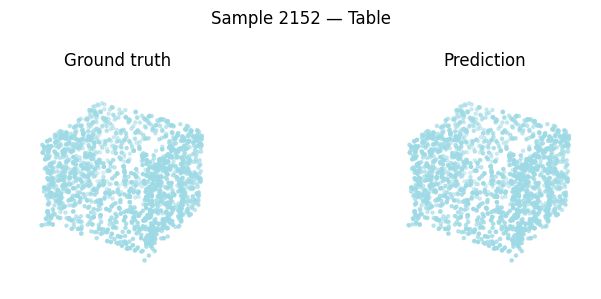

[W1112 21:45:11.844420993 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:45:13.523766702 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_1044_20251112-214521.png


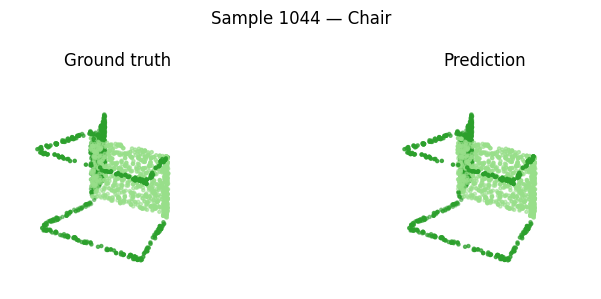

[W1112 21:45:22.392570705 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:45:24.223911414 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_2080_20251112-214532.png


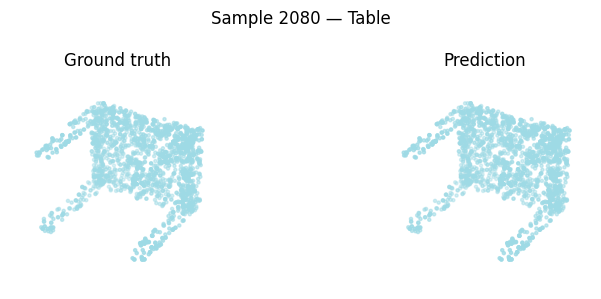

[W1112 21:45:32.977026288 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:45:34.729163591 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_698_20251112-214543.png


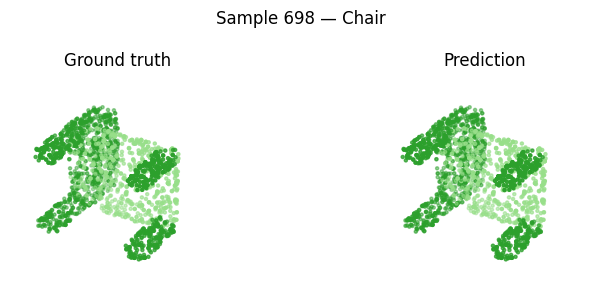

[W1112 21:45:43.560339258 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:45:45.323457677 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_589_20251112-214553.png


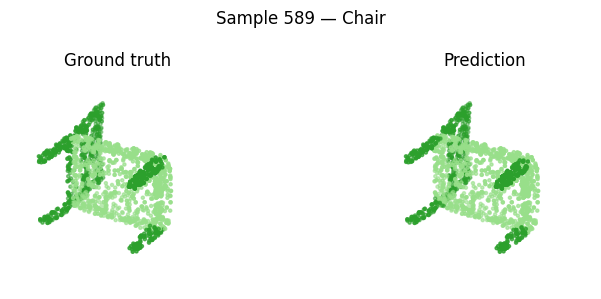

[W1112 21:45:53.084418217 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:45:55.734704491 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_1450_20251112-214603.png


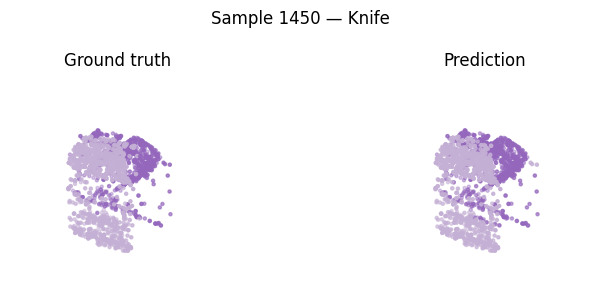

[W1112 21:46:04.297320423 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:46:05.028220667 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_2566_20251112-214613.png


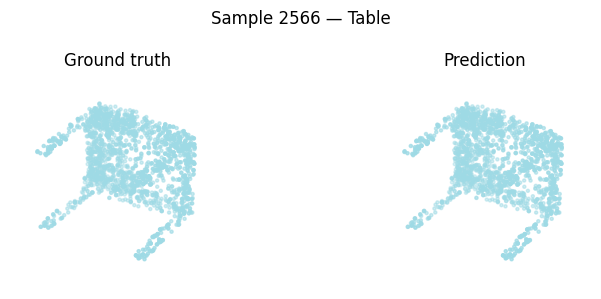

[W1112 21:46:14.402200196 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:46:16.137790592 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_370_20251112-214624.png


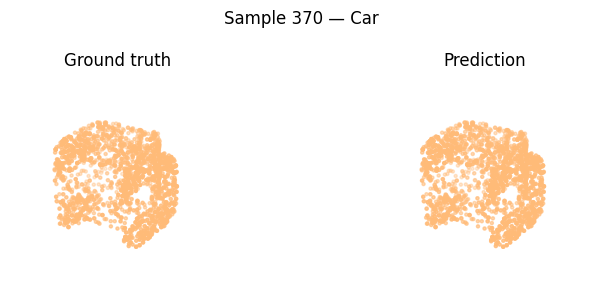

[W1112 21:46:25.153736675 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:46:26.731390074 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_1610_20251112-214635.png


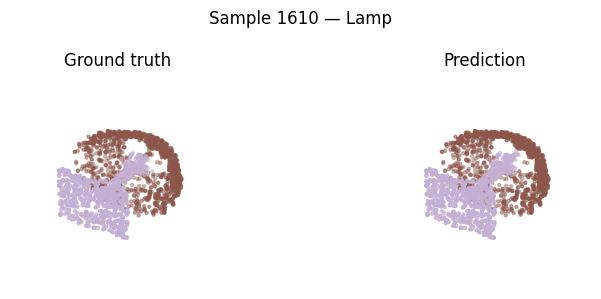

[W1112 21:46:35.809016825 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1112 21:46:37.523279134 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved figure to /workspace/comp3419_A2b/Pointnet_Pointnet2_pytorch/log/part_seg/pointnet_partseg_xyz_runpod/figures/sample_1471_20251112-214645.png


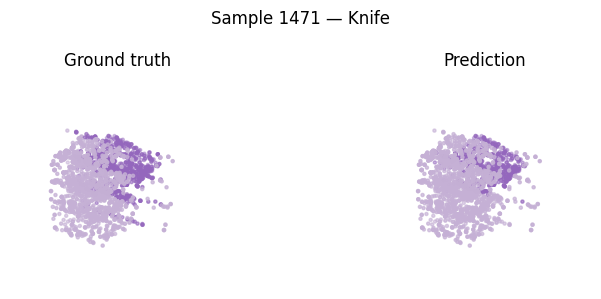

In [72]:
#@title 11) Visualize qualitative segmentation samples
import importlib
import random
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
MODELS_DIR = REPO_DIR / 'models'
if str(MODELS_DIR) not in sys.path:
    sys.path.insert(0, str(MODELS_DIR))

from data_utils.ShapeNetDataLoader import PartNormalDataset
FIG_DIR = LOG_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEG_CLASSES = {'Earphone': [16, 17, 18], 'Motorbike': [30, 31, 32, 33, 34, 35], 'Rocket': [41, 42, 43],
               'Car': [8, 9, 10, 11], 'Laptop': [28, 29], 'Cap': [6, 7], 'Skateboard': [44, 45, 46],
               'Mug': [36, 37], 'Guitar': [19, 20, 21], 'Bag': [4, 5], 'Lamp': [24, 25, 26, 27],
               'Table': [47, 48, 49], 'Airplane': [0, 1, 2, 3], 'Pistol': [38, 39, 40],
               'Chair': [12, 13, 14, 15], 'Knife': [22, 23]}
SEG_LABEL_TO_CAT = {label: cat for cat, labels in SEG_CLASSES.items() for label in labels}
NUM_PART = 50
NUM_CLASS = 16


def to_categorical(y):
    out = torch.zeros((y.shape[0], NUM_CLASS), dtype=torch.float32)
    out.scatter_(1, y.unsqueeze(1), 1)
    return out


@torch.no_grad()
def load_partseg_model():
    exp_dir = REPO_DIR / 'log' / 'part_seg' / EXP_NAME
    log_files = sorted((exp_dir / 'logs').glob('*.py'))
    if not log_files:
        log_files = sorted(exp_dir.glob('*.py'))
    if not log_files:
        raise FileNotFoundError('No logged model definition found in ' + str(exp_dir))
    module_path = log_files[0]
    module_name = module_path.stem
    if module_name == 'pointnet2_utils':
        module_name = 'pointnet_part_seg'
        module_path = exp_dir / (module_name + '.py')
    search_dirs = [module_path.parent, exp_dir, REPO_DIR / 'models']
    for extra in search_dirs:
        extra_str = str(extra)
        if extra_str not in sys.path:
            sys.path.insert(0, extra_str)
    module = importlib.import_module(module_name)
    model = module.get_model(NUM_PART, normal_channel=False)
    ckpt_path = exp_dir / 'checkpoints/best_model.pth'
    try:
        checkpoint = torch.load(ckpt_path, map_location='cpu')
    except Exception as err:
        if 'weights only load failed' in str(err).lower():
            checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        else:
            raise
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model


@torch.no_grad()
def visualize_samples(num_samples=5):
    dataset_root = REPO_DIR / 'data' / 'shapenetcore_partanno_segmentation_benchmark_v0_normal'
    dataset = PartNormalDataset(root=str(dataset_root), npoints=NUM_POINTS, split='test', normal_channel=False)
    idx_to_cat = {v: k for k, v in dataset.classes.items()}
    model = load_partseg_model()
    cmap = plt.get_cmap('tab20', NUM_PART)
    indices = random.sample(range(len(dataset)), k=min(num_samples, len(dataset)))
    for idx in indices:
        points, cls, target = dataset[idx]
        pts_tensor = torch.from_numpy(points).unsqueeze(0).float()
        pts_transposed = pts_tensor.transpose(2, 1)
        label = torch.from_numpy(cls).long()
        logits, _ = model(pts_transposed, to_categorical(label))
        logits = logits.squeeze(0).cpu().numpy()
        pred_labels = np.zeros(NUM_POINTS, dtype=int)
        for i in range(NUM_POINTS):
            cat = SEG_LABEL_TO_CAT[int(target[i])]
            part_indices = SEG_CLASSES[cat]
            idx_local = np.argmax(logits[i, part_indices])
            pred_labels[i] = part_indices[idx_local]
        fig = plt.figure(figsize=(8, 3))
        fig.suptitle(f'Sample {idx} — {idx_to_cat[int(cls[0])]}')
        for col, (labels, title) in enumerate([(target, 'Ground truth'), (pred_labels, 'Prediction')]):
            ax = fig.add_subplot(1, 2, col + 1, projection='3d')
            ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=cmap(labels % NUM_PART), s=5)
            ax.set_title(title)
            ax.set_axis_off()
        plt.tight_layout()
        timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
        fig_path = FIG_DIR / f'sample_{idx}_{timestamp}.png'
        fig.savefig(fig_path, dpi=200, bbox_inches='tight')
        print('Saved figure to', fig_path)
        plt.show()
        plt.close(fig)

visualize_samples(num_samples=10)



In [66]:
#@title 12) Tail logs for report
from pathlib import Path

def tail(path, n=20):
    if not path.exists():
        return []
    with open(path) as f:
        lines = f.readlines()
    return lines[-n:]

print('=== Train tail ===')
print(''.join(tail(LOG_DIR / 'console_train.txt')))
print('=== Eval tail ===')
print(''.join(tail(LOG_DIR / 'console_eval.txt')))


=== Train tail ===
eval mIoU of Airplane       0.937756
eval mIoU of Bag            0.717649
eval mIoU of Cap            0.719199
eval mIoU of Car            0.912826
eval mIoU of Chair          0.947680
eval mIoU of Earphone       0.850685
eval mIoU of Guitar         0.931241
eval mIoU of Knife          0.830657
eval mIoU of Lamp           0.919177
eval mIoU of Laptop         0.947002
eval mIoU of Motorbike      0.913883
eval mIoU of Mug            0.896135
eval mIoU of Pistol         0.846357
eval mIoU of Rocket         0.850027
eval mIoU of Skateboard     0.893111
eval mIoU of Table          0.940358
Epoch 250 test Accuracy: 0.948857  Class avg mIOU: 0.878359   Inctance avg mIOU: 0.929088
Best accuracy is: 0.94915
Best class avg mIOU is: 0.88034
Best inctance avg mIOU is: 0.92942

=== Eval tail ===
eval mIoU of Airplane       0.937556
eval mIoU of Bag            0.705304
eval mIoU of Cap            0.731418
eval mIoU of Car            0.913359
eval mIoU of Chair          0.948147
ev

In [ ]:
#@title 13) Export artifacts
import shutil
import subprocess
import time
from datetime import datetime
from pathlib import Path

if not LOG_DIR.exists():
    raise FileNotFoundError(f'LOG_DIR not found at {LOG_DIR}. Run training/eval first.')

EXPORT_BASE = NOTEBOOK_DIR / 'pointnet_partseg_artifacts'
EXPORT_BASE.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
TARGET = EXPORT_BASE / f"{EXP_NAME}_{timestamp}"
if TARGET.exists():
    shutil.rmtree(TARGET)
TARGET.mkdir(parents=True, exist_ok=True)
shutil.copytree(LOG_DIR, TARGET / 'log')
notebook_src = NOTEBOOK_DIR / 'PointNet_ShapeNetPart_Runpod.ipynb'
if notebook_src.exists():
    shutil.copy2(notebook_src, TARGET / notebook_src.name)
note_text = (
    'Exported at ' + time.ctime() + '\n'
    + 'Repo commit: ' + subprocess.getoutput(f"cd '{REPO_DIR}' && git rev-parse HEAD") + '\n'
)
(TARGET / 'NOTE.txt').write_text(note_text)
archive_path = shutil.make_archive(str(TARGET), 'zip', root_dir=TARGET)
print('Exported folder :', TARGET)
print('Archived bundle:', archive_path)
